# Fadli Haidar Nugraha


## Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('cardio_train.csv', sep=';')

print("Jumlah data awal:", df.shape)
df.head()

Jumlah data awal: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Konversi Umur (days to years)

In [2]:
# Mengubah hari ke tahun (menggunakan 365.25 untuk mengakomodasi tahun kabisat)
df['age_years'] = (df['age'] / 365.25).round().astype(int)

# Drop kolom 'age' yang lama agar tidak membingungkan model
df = df.drop('age', axis=1)

Checking outliers

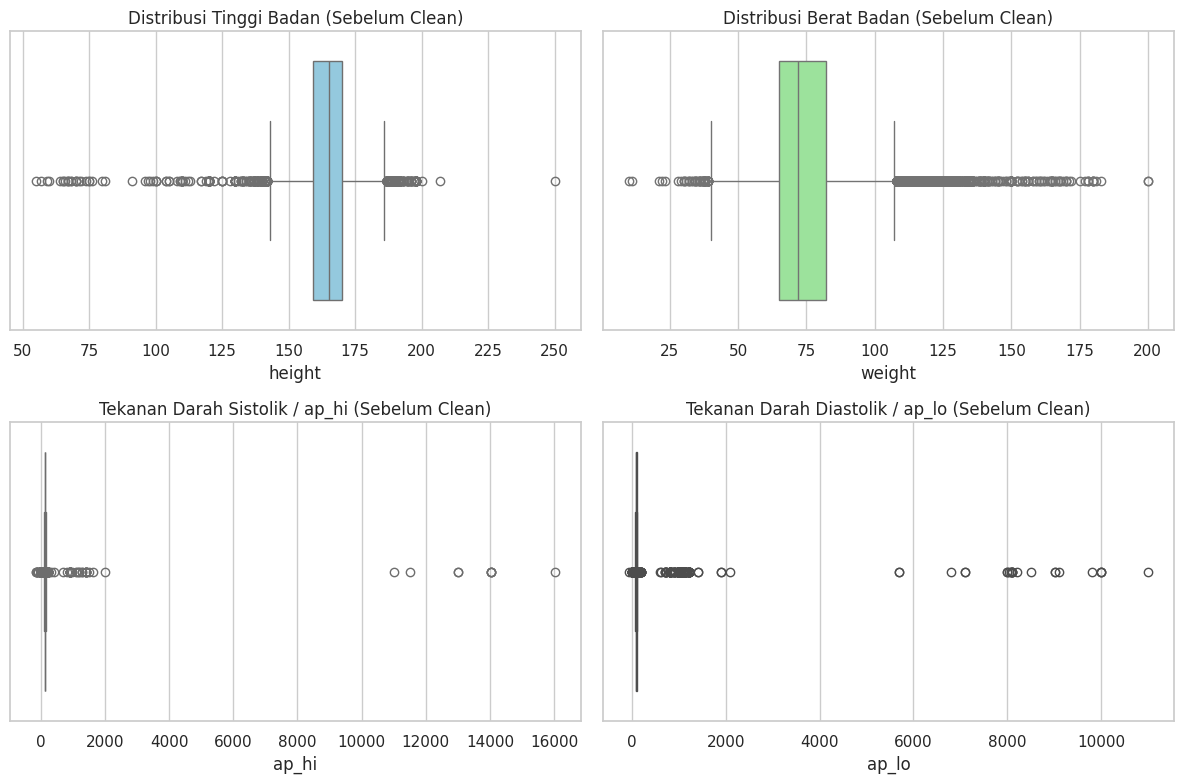

In [3]:
# Mengatur tema visual
sns.set_theme(style="whitegrid")

# Membuat canvas berukuran 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Boxplot untuk Tinggi Badan
sns.boxplot(x=df['height'], color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Tinggi Badan (Sebelum Clean)')

# 2. Boxplot untuk Berat Badan
sns.boxplot(x=df['weight'], color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Berat Badan (Sebelum Clean)')

# 3. Boxplot untuk Tekanan Darah Sistolik (ap_hi)
sns.boxplot(x=df['ap_hi'], color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Tekanan Darah Sistolik / ap_hi (Sebelum Clean)')

# 4. Boxplot untuk Tekanan Darah Diastolik (ap_lo)
sns.boxplot(x=df['ap_lo'], color='gold', ax=axes[1, 1])
axes[1, 1].set_title('Tekanan Darah Diastolik / ap_lo (Sebelum Clean)')

plt.tight_layout()
plt.show()

Sebelum melakukan pembersihan data, kita melakukan pengecekan distribusi fitur numerik menggunakan Boxplot. Dari grafik di atas, terlihat jelas adanya anomali ekstrim (outliers) pada kolom tekanan darah, tinggi, dan berat badan yang sangat jauh dari batas normal manusia.

Cleaning outliers (tensi darah)

Berdasarkan referensi medis dari WHO, tekanan darah sistolik di atas 250 mmHg atau di bawah 80 mmHg pada pasien rawat jalan dianggap sebagai anomali pengukuran (error instrumen). Oleh karena itu, data di luar rentang tersebut akan dieliminasi.

In [4]:
# Filter batas atas dan bawah
# Sistolik (ap_hi) wajar: 80 - 250 mmHg
# Diastolik (ap_lo) wajar: 50 - 150 mmHg
df_clean = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df_clean = df_clean[(df_clean['ap_lo'] >= 50) & (df_clean['ap_lo'] <= 150)]

# Aturan Medis: Tensi sistolik (ap_hi) harus lebih tinggi dari diastolik (ap_lo)
df_clean = df_clean[df_clean['ap_hi'] > df_clean['ap_lo']]

print("Jumlah data setelah membersihkan outlier tensi:", df_clean.shape)

Jumlah data setelah membersihkan outlier tensi: (68645, 13)


Cleaning outliers (tinggi & berat badan)

In [5]:
# Batas wajar untuk dewasa: Tinggi 130 - 210 cm, Berat 35 - 200 kg
df_clean = df_clean[(df_clean['height'] >= 130) & (df_clean['height'] <= 210)]
df_clean = df_clean[(df_clean['weight'] >= 35) & (df_clean['weight'] <= 200)]

print("Jumlah data setelah membersihkan outlier fisik:", df_clean.shape)

Jumlah data setelah membersihkan outlier fisik: (68540, 13)


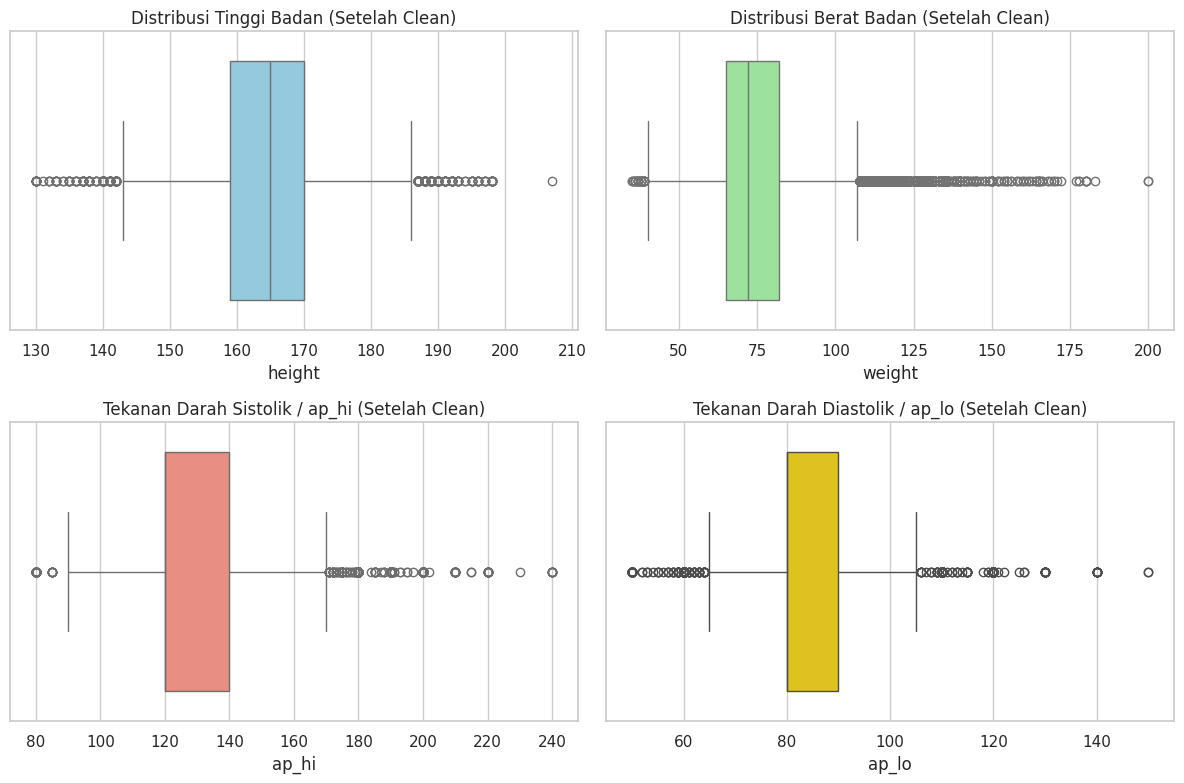

In [6]:
# Membuat canvas berukuran 2x2 untuk data yang sudah bersih
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Boxplot untuk Tinggi Badan (Setelah Clean)
sns.boxplot(x=df_clean['height'], color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Tinggi Badan (Setelah Clean)')

# 2. Boxplot untuk Berat Badan (Setelah Clean)
sns.boxplot(x=df_clean['weight'], color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Distribusi Berat Badan (Setelah Clean)')

# 3. Boxplot untuk Tekanan Darah Sistolik (Setelah Clean)
sns.boxplot(x=df_clean['ap_hi'], color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Tekanan Darah Sistolik / ap_hi (Setelah Clean)')

# 4. Boxplot untuk Tekanan Darah Diastolik (Setelah Clean)
sns.boxplot(x=df_clean['ap_lo'], color='gold', ax=axes[1, 1])
axes[1, 1].set_title('Tekanan Darah Diastolik / ap_lo (Setelah Clean)')

plt.tight_layout()
plt.show()

Check null values

In [7]:
# Mengecek jumlah missing values (null) di setiap kolom
print("Jumlah Null Value per Kolom:")
print(df_clean.isnull().sum())

# Mengecek persentase missing values (opsional, tapi bagus untuk report)
print("\nPersentase Null Value:")
print((df_clean.isnull().sum() / len(df_clean)) * 100)

Jumlah Null Value per Kolom:
id             0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Persentase Null Value:
id             0.0
gender         0.0
height         0.0
weight         0.0
ap_hi          0.0
ap_lo          0.0
cholesterol    0.0
gluc           0.0
smoke          0.0
alco           0.0
active         0.0
cardio         0.0
age_years      0.0
dtype: float64


Feature Engineering (BMI)

Untuk memberikan representasi risiko kesehatan yang lebih holistik kepada model klasifikasi, dilakukan rekayasa fitur (feature engineering) berupa kalkulasi Body Mass Index (BMI)

In [8]:
# Rumus BMI: Berat (kg) / (Tinggi (m))^2
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)
df_clean['bmi'] = df_clean['bmi'].round(2)

# Opsional: Melihat distribusi data yang sudah bersih
df_clean.describe()

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000
mean,49975.724365,1.348658,164.441596,74.119829,126.677546,81.316487,1.364780,1.225737,0.088007,0.053370,0.803429,0.494733,53.293011,27.444246
std,28846.414874,0.476549,7.844436,14.279722,16.673039,9.397989,0.678984,0.571624,0.283307,0.224772,0.397408,0.499976,6.761936,5.203243
min,0.000000,1.000000,130.000000,35.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,12.250000
25%,25006.750000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.880000
50%,50014.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,26.350000
75%,74870.750000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.120000
max,99999.000000,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,85.780000


In [11]:
df_clean.describe()

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000
mean,49975.724365,1.348658,164.441596,74.119829,126.677546,81.316487,1.364780,1.225737,0.088007,0.053370,0.803429,0.494733,53.293011,27.444246
std,28846.414874,0.476549,7.844436,14.279722,16.673039,9.397989,0.678984,0.571624,0.283307,0.224772,0.397408,0.499976,6.761936,5.203243
min,0.000000,1.000000,130.000000,35.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,12.250000
25%,25006.750000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.880000
50%,50014.500000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,26.350000
75%,74870.750000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.120000
max,99999.000000,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,85.780000


In [12]:
# Drop kolom id karena tidak relevan untuk pemodelan
df_clean = df_clean.drop('id', axis=1)

In [13]:
df_clean.describe()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000,68540.000000
mean,1.348658,164.441596,74.119829,126.677546,81.316487,1.364780,1.225737,0.088007,0.053370,0.803429,0.494733,53.293011,27.444246
std,0.476549,7.844436,14.279722,16.673039,9.397989,0.678984,0.571624,0.283307,0.224772,0.397408,0.499976,6.761936,5.203243
min,1.000000,130.000000,35.000000,80.000000,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,12.250000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.880000
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,26.350000
75%,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.120000
max,2.000000,207.000000,200.000000,240.000000,150.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,85.780000


In [14]:
# Menyimpan dataset yang sudah bersih untuk proses training AI
df_clean.to_csv('cardio_cleaned.csv', index=False)

In [18]:
df_ai_ready = df_clean.drop(['bmi_category'], axis=1)

# Simpan dataset yang sudah 100% numerik untuk proses training AI
df_ai_ready.to_csv('cardio_cleaned.csv', index=False)

print("Data berhasil disiapkan untuk AI! Jumlah kolom:", df_ai_ready.shape[1])

Data berhasil disiapkan untuk AI! Jumlah kolom: 13


In [28]:
# Memindahkan kolom 'cardio' ke paling belakang
cols = [col for col in df_clean.columns if col != 'cardio'] + ['cardio']
df_clean = df_clean[cols]

In [30]:
# Simpan dataset yang sudah 100% numerik untuk proses training AI
df_clean.to_csv('cardio_cleaned.csv', index=False)

print("Data berhasil disiapkan! Jumlah kolom:", df_clean.shape[1])

df_clean.head()

Data berhasil disiapkan! Jumlah kolom: 13


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,cardio
0,2,168,62.0,110,80,1,1,0,0,1,50,21.97,0
1,1,156,85.0,140,90,3,1,0,0,1,55,34.93,1
2,1,165,64.0,130,70,3,1,0,0,0,52,23.51,1
3,2,169,82.0,150,100,1,1,0,0,1,48,28.71,1
4,1,156,56.0,100,60,1,1,0,0,0,48,23.01,0
